In [32]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import fractional_matrix_power
from psyduck import Spin
from psyduck.operations import *
from psyduck.hamiltonians import zeeman_hamiltonian, hyperfine_hamiltonian, quadrupole_hamiltonian
from psyduck.plotting import plot_transition_matrix_simplified
from psyduck.plotting.readout_plot import plot_transition_matrix, plot_transition_matrix_simplified

# Build Hamiltonian model

In [33]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()

electron = Spin(I=1/2)
Sx, Sy, Sz = electron.get_spin_operators()

In [34]:
H_quad

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.07880392+0.j          0.02065942-0.04084895j -0.03123099+0.13967142j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.02065942+0.04084895j  0.0112577 +0.j          0.01803302-0.03565589j
  -0.04571749+0.20445803j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.03123099-0.13967142j  0.01803302+0.03565589j -0.03377311+0.j
   0.01008077-0.01993225j -0.05279   +0.23608779j  0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j         -0.04571749-0.20445803j  0.01008077+0.01993225j
  -0.05628851+0.j          0.        +0.j         -0.05279   +0.23608779j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.05279   -0.23608779j
   0.        +0.j         -0.05628851+0.j         -0.01008077+0.0

In [35]:
H_quad = qt.Qobj(np.load('../quadrupole modeling/H_quad_fit.npy')) # from fit
# H_quad = quadrupole_hamiltonian(I=7/2, f_q=22e-3, eta=0.4)
# H_quad_neutral = np.load('../quadrupole modeling/H_quad_neutral.npy') # from fit
Hz_nucleus = zeeman_hamiltonian(7/2, B0=1.07, gamma=5.55)
Hz_electron = zeeman_hamiltonian(1/2, B0=1.07, gamma=28.8e3)
H_ionized = Hz_nucleus + H_quad  # Note: zeeman_hamiltonian already includes the -γ sign
H_hyperfine = hyperfine_hamiltonian(S=1/2, I=7/2, A=1/17)
H_neutral = qt.tensor(Hz_electron, qt.qeye(8)) + qt.tensor(qt.qeye(2), H_ionized) - H_hyperfine

In [36]:
P_donor = qt.tensor(qt.Qobj(np.array([[1, 0], [0, 1], [0, 0]])), qt.qeye(8))
P_SET = qt.tensor(qt.Qobj(np.array([0, 0, 1])), qt.qeye(8))

H_neutral_full = qt.Qobj(P_donor.full() @ H_neutral.full() @ P_donor.dag().full())
H_ionized_full = qt.Qobj(P_SET.full() @ H_ionized.full() @ P_SET.dag().full())
H_full = H_neutral_full + H_ionized_full

## Visualize Hamiltonian

Text(0, 0.5, 'Row Index')

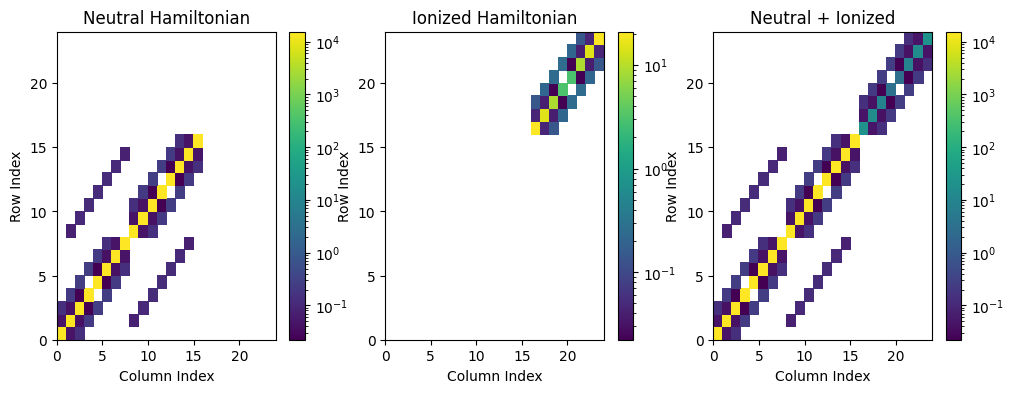

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
pcm1 = ax[0].pcolor(np.abs(H_neutral_full.full()), norm=LogNorm())
pcm2 = ax[1].pcolor(np.abs(H_ionized_full.full()), norm=LogNorm())
pcm3 = ax[2].pcolor(np.abs(H_full.full()), norm=LogNorm())
plt.colorbar(pcm1, ax=ax[0])
plt.colorbar(pcm2, ax=ax[1])
plt.colorbar(pcm3, ax=ax[2])
ax[0].set_title('Neutral Hamiltonian')
ax[1].set_title('Ionized Hamiltonian')
ax[2].set_title('Neutral + Ionized')

ax[0].set_xlabel('Column Index')
ax[0].set_ylabel('Row Index')
ax[1].set_xlabel('Column Index')
ax[1].set_ylabel('Row Index')
ax[2].set_xlabel('Column Index')
ax[2].set_ylabel('Row Index')

## compute eigenvalues and eigenvectors

In [38]:
(eigenvalues_full, eigenstates_full) = H_full.eigenstates()
eigenstate_full_matrix = np.zeros([24,24], dtype=complex)
for i in range(24):
    idx_argmax = np.argmax(np.abs(eigenstates_full[i].full().flatten())**2)
    eigenstate_full_matrix[idx_argmax] = eigenstates_full[i].full().flatten()

<Axes: >

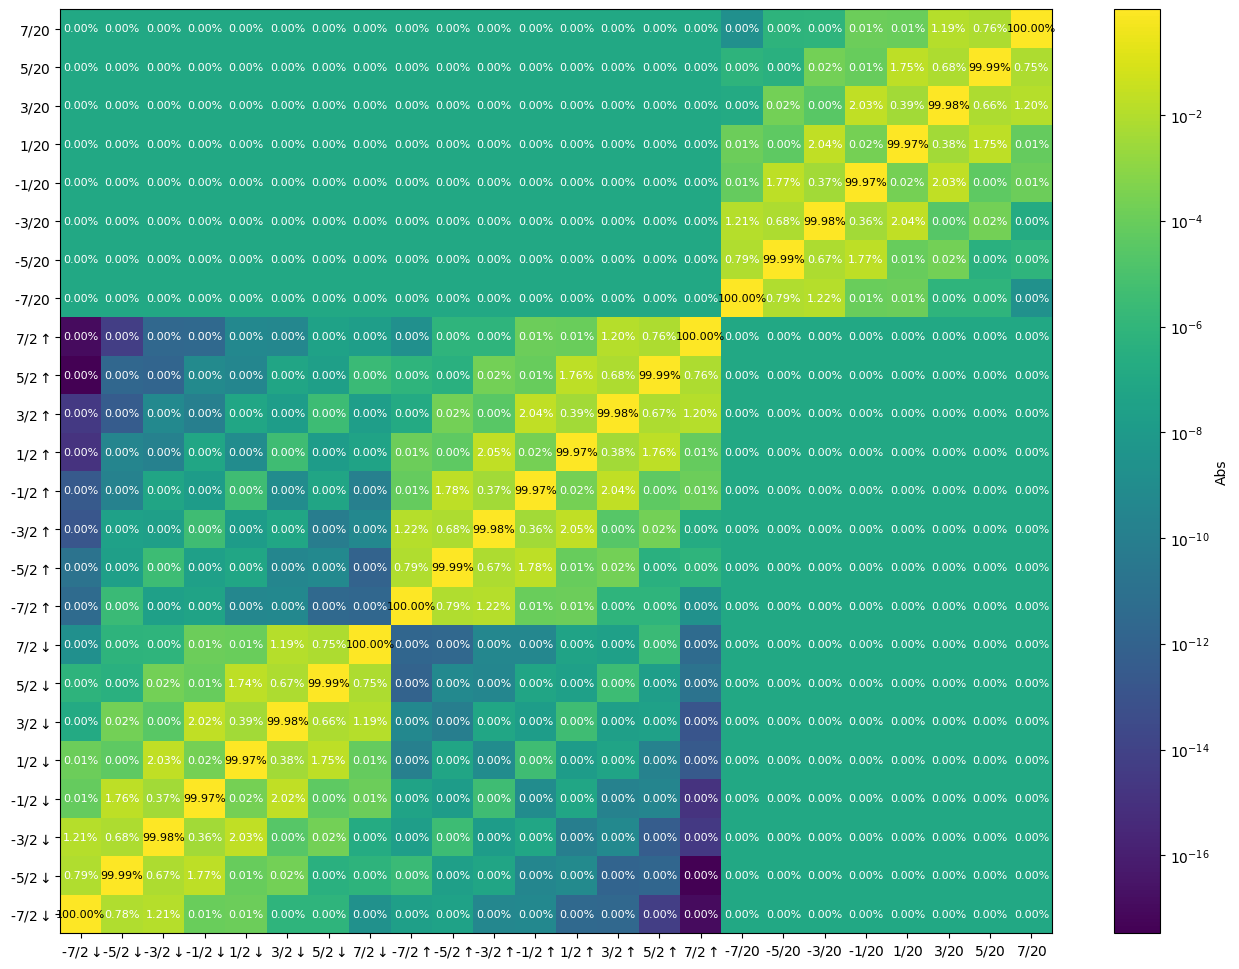

In [39]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
plot_transition_matrix(eigenstate_full_matrix, electron_states=3, ax=ax)

In [40]:
nmr_freqs = np.zeros(7)
for i in range(len(nmr_freqs)):
    nmr_freqs[i] = eigenvalues_full[8+i] - eigenvalues_full[8+i+1]

ESR_freqs = np.diff(np.abs(eigenvalues_full[:8] - eigenvalues_full[16:][::-1]))

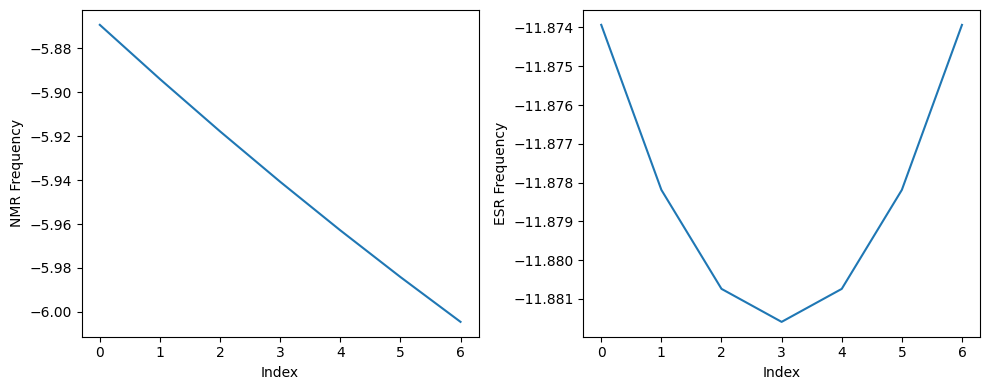

In [41]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(nmr_freqs)
ax[0].set_xlabel('Index')
ax[0].set_ylabel('NMR Frequency')
ax[1].plot(ESR_freqs)
ax[1].set_xlabel('Index')
ax[1].set_ylabel('ESR Frequency')
plt.tight_layout()

# Calculate ionization shock

In [42]:
# Compute transition probabilities via direct projection
#
# Hilbert space layout (electron ⊗ nucleus, embedded in 24-dim space):
#   indices  0- 7: |e↑⟩ ⊗ |mI⟩   (spin-up electron, neutral)
#   indices  8-15: |e↓⟩ ⊗ |mI⟩   (spin-down electron, neutral)
#   indices 16-23: |SET⟩ ⊗ |mI⟩  (ionized, no electron)
#
# eigenstate_full_matrix[k, :] = eigenstate whose dominant basis element is k.
# For ionise_up: donor had ↑ electron  → neutral eigenstates in rows 0-7,  nuclear part in cols :8
# For ionise_down: donor had ↓ electron → neutral eigenstates in rows 8-15, nuclear part in cols 8:16

transition_matrix_ionize_up   = np.zeros((8, 8))
transition_matrix_ionize_down = np.zeros((8, 8))

for i in range(8):
    for j in range(8):
        ion_state = eigenstate_full_matrix[16 + j, 16:]   # nuclear part of ionized eigenstate j

        # Ionisation from spin-UP donor electron (rows 0-7)
        psi_up = eigenstate_full_matrix[i, :8]            # dominant (↑) nuclear part
        psi_up_minor = eigenstate_full_matrix[i, 8:16]    # small ↓ admixture
        transition_matrix_ionize_up[i, j] = (
            np.abs(np.dot(psi_up.conj(), ion_state))**2
            + np.abs(np.dot(psi_up_minor.conj(), ion_state))**2
        )

        # Ionisation from spin-DOWN donor electron (rows 8-15)
        psi_down = eigenstate_full_matrix[8 + i, 8:16]    # dominant (↓) nuclear part
        psi_down_minor = eigenstate_full_matrix[8 + i, :8] # small ↑ admixture
        transition_matrix_ionize_down[i, j] = (
            np.abs(np.dot(psi_down.conj(), ion_state))**2
            + np.abs(np.dot(psi_down_minor.conj(), ion_state))**2
        )

# For a sudden ionisation shock the reverse (neutralisation) transition matrix
# is the transpose (time-reversal): P(j→i) = P(i→j)
transition_matrix_neutralize_up   = transition_matrix_ionize_up.T.copy()
transition_matrix_neutralize_down = transition_matrix_ionize_down.T.copy()

<Axes: title={'center': 'Neutralization from |SET> to |down>'}>

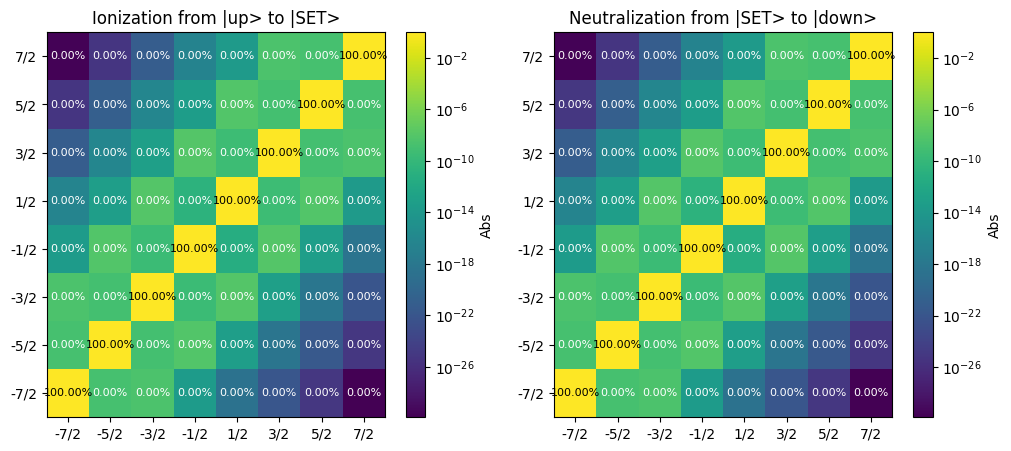

In [43]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

title_ionize = 'Ionization from |up> to |SET>'
plot_transition_matrix(transition_matrix_ionize_up, ax=ax[0], electron_states=1, title=title_ionize)
title_neutralize = 'Neutralization from |SET> to |down>'
plot_transition_matrix(transition_matrix_neutralize_down, ax=ax[1], electron_states=1, title=title_neutralize)

In [46]:
1-np.diag(transition_matrix_ionize_up)

array([5.24116617e-09, 1.04187352e-08, 1.52314890e-08, 1.80363432e-08,
       1.79212384e-08, 1.48577345e-08, 9.79798909e-09, 4.72973072e-09])

In [44]:
transition_matrix_ionize_up

array([[9.99999995e-01, 1.57656331e-09, 3.66457880e-09, 2.44654782e-14,
        2.04998108e-19, 1.13354499e-22, 6.80264669e-26, 1.19499899e-30],
       [1.58283350e-09, 9.99999990e-01, 1.11114804e-09, 7.72470055e-09,
        5.29251097e-14, 5.38161481e-19, 1.87428333e-22, 6.39270881e-26],
       [3.66468543e-09, 1.12191250e-09, 9.99999985e-01, 3.06293221e-10,
        1.01385359e-08, 6.28179433e-14, 6.54017553e-19, 1.05599204e-22],
       [2.59072283e-14, 7.72476003e-09, 3.19905751e-10, 9.99999982e-01,
        5.08696467e-12, 9.98651655e-09, 4.78737935e-14, 3.66113204e-19],
       [3.36929663e-17, 5.44184171e-14, 1.01385275e-08, 1.96634691e-11,
        9.99999982e-01, 3.80670931e-10, 7.38230217e-09, 2.00171173e-14],
       [6.61720795e-22, 6.79623505e-17, 6.27099342e-14, 9.98652598e-09,
        3.94251522e-10, 9.99999985e-01, 1.07917870e-09, 3.39771596e-09],
       [5.65111936e-26, 1.03483179e-21, 6.40769338e-17, 4.63951685e-14,
        7.38238155e-09, 1.08994549e-09, 9.99999990e-01, 1.

In [58]:
np.save(r'sims_data/neutralization_down_matrix.npy', np.abs(transition_matrix_neutralize_down))
np.save(r'sims_data/ionization_up_matrix.npy', np.abs(transition_matrix_ionize_up))

<Axes: title={'center': 'Estimated transition matrix through direct projection'}>

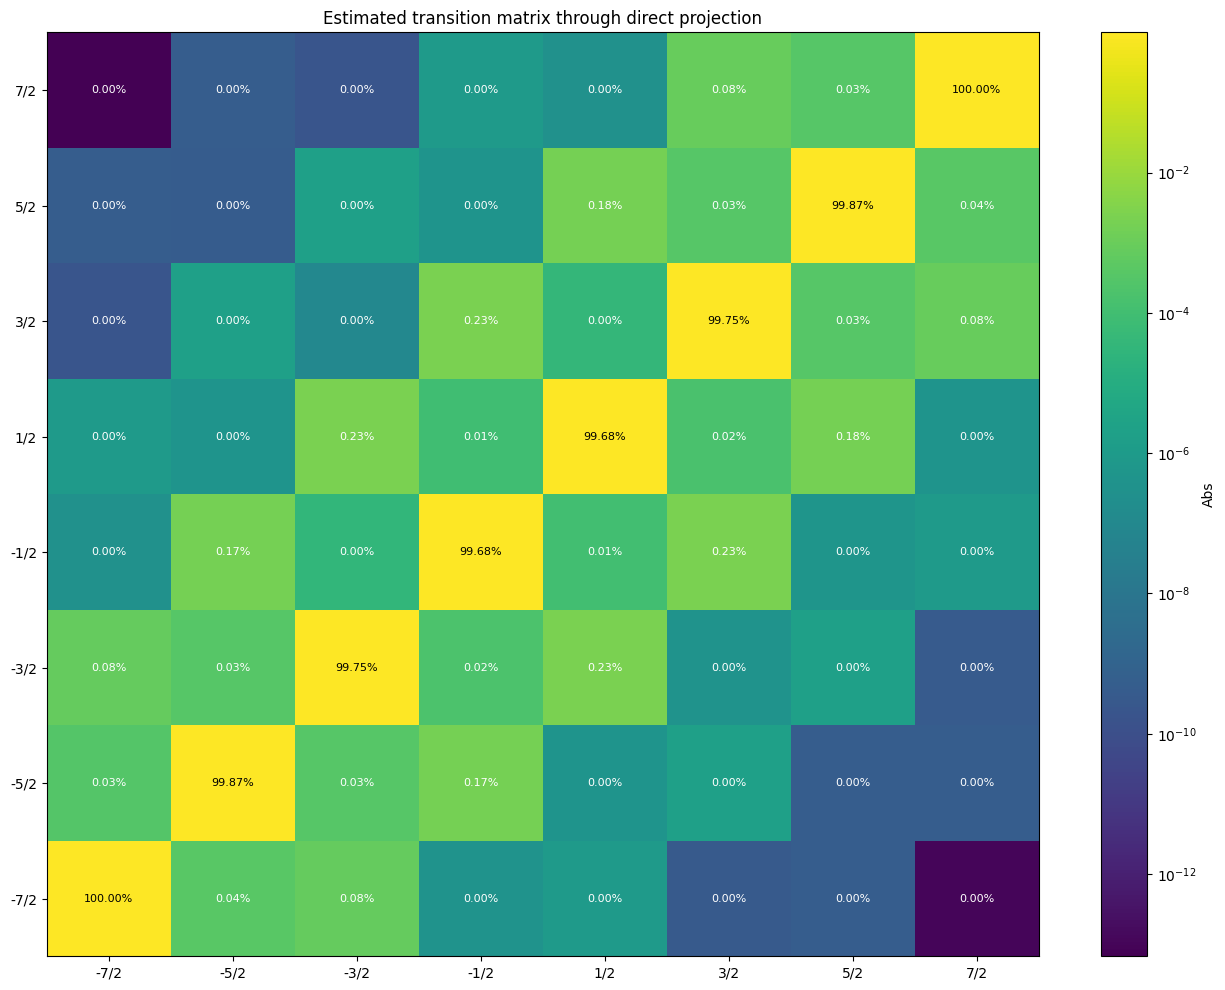

In [59]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
n_tunnel = 4.47
T_est = fractional_matrix_power(np.abs(transition_matrix_neutralize_down) @ np.abs(transition_matrix_ionize_up), n_tunnel)

plot_transition_matrix(T_est, electron_states=1, ax=ax, title='Estimated transition matrix through direct projection')

In [60]:
np.save(r'sims_data/ionization_matrix_proj.npy', T_est)